In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [13]:
problems = ["inverted_double_pendulum", "reacher", "swimmer", "hopper", "walker2d", "halfcheetah"]
seeds = range(0, 10)
algorithms = ["ga", "gomea"]
solvers = ["cgp", "lgp"]

missing = 0
dfs = []
for algorithm in algorithms:
    for solver in solvers:
        for problem in problems:
            for pop in ["small", "large"]:  #, "diverse"]:
                div = "_large_pop" if pop == "large" else ("_diversity" if pop == "diverse" else "")
                for seed in seeds:
                    if algorithm == "gomea":
                        for fos in ["U", "RT", "LT",  "LT1"]:#, "N1", "N2"]:
                            try:
                                tmp_df = pd.read_csv(
                                    f"../results/control/{algorithm}_{solver}_{problem}_{fos}_{seed}_fi{div}.csv")
                            except FileNotFoundError as e:
                                missing += 1
                                print(f"{algorithm}_{solver}_{problem}_{fos}_{seed}_fi{div}")
                                continue
                            tmp_df["seed"] = seed
                            tmp_df["pop"] = pop
                            tmp_df["algorithm"] = f"{algorithm}_{fos}"
                            tmp_df["problem"] = problem
                            tmp_df["solver"] = solver
                            dfs.append(tmp_df)
                    else:
                        if pop == "diverse":
                            continue
                        try:
                            tmp_df = pd.read_csv(f"../results/control/{algorithm}_{solver}_{problem}_{seed}{div}.csv")
                        except FileNotFoundError as e:
                            missing += 1
                            print(f"{algorithm}_{solver}_{problem}_{seed}_fi{div}")
                            continue
                        tmp_df["seed"] = seed
                        tmp_df["algorithm"] = algorithm
                        tmp_df["problem"] = problem
                        tmp_df["solver"] = solver
                        tmp_df["pop"] = pop
                        dfs.append(tmp_df)
control_df = pd.concat(dfs, ignore_index=True)
print(missing)
control_df.head()

gomea_cgp_walker2d_LT1_1_fi_large_pop
gomea_cgp_walker2d_LT1_6_fi_large_pop
gomea_cgp_walker2d_LT1_7_fi_large_pop
gomea_cgp_halfcheetah_LT1_1_fi_large_pop
gomea_cgp_halfcheetah_LT1_6_fi_large_pop
gomea_cgp_halfcheetah_LT1_7_fi_large_pop
6


,evaluation,fitness,uniqueness,time,seed,algorithm,problem,solver,pop
0,100,774.673889,1.0,69.76,0,ga,inverted_double_pendulum,cgp,small
1,190,843.073914,1.0,72.05,0,ga,inverted_double_pendulum,cgp,small
2,280,870.539795,1.0,13.53,0,ga,inverted_double_pendulum,cgp,small
3,370,870.539795,1.0,13.23,0,ga,inverted_double_pendulum,cgp,small
4,460,870.539795,1.0,12.58,0,ga,inverted_double_pendulum,cgp,small


In [3]:
rounding_factor = 1000
control_df["rounded_evaluation"] = (control_df["evaluation"] / rounding_factor).round() * rounding_factor

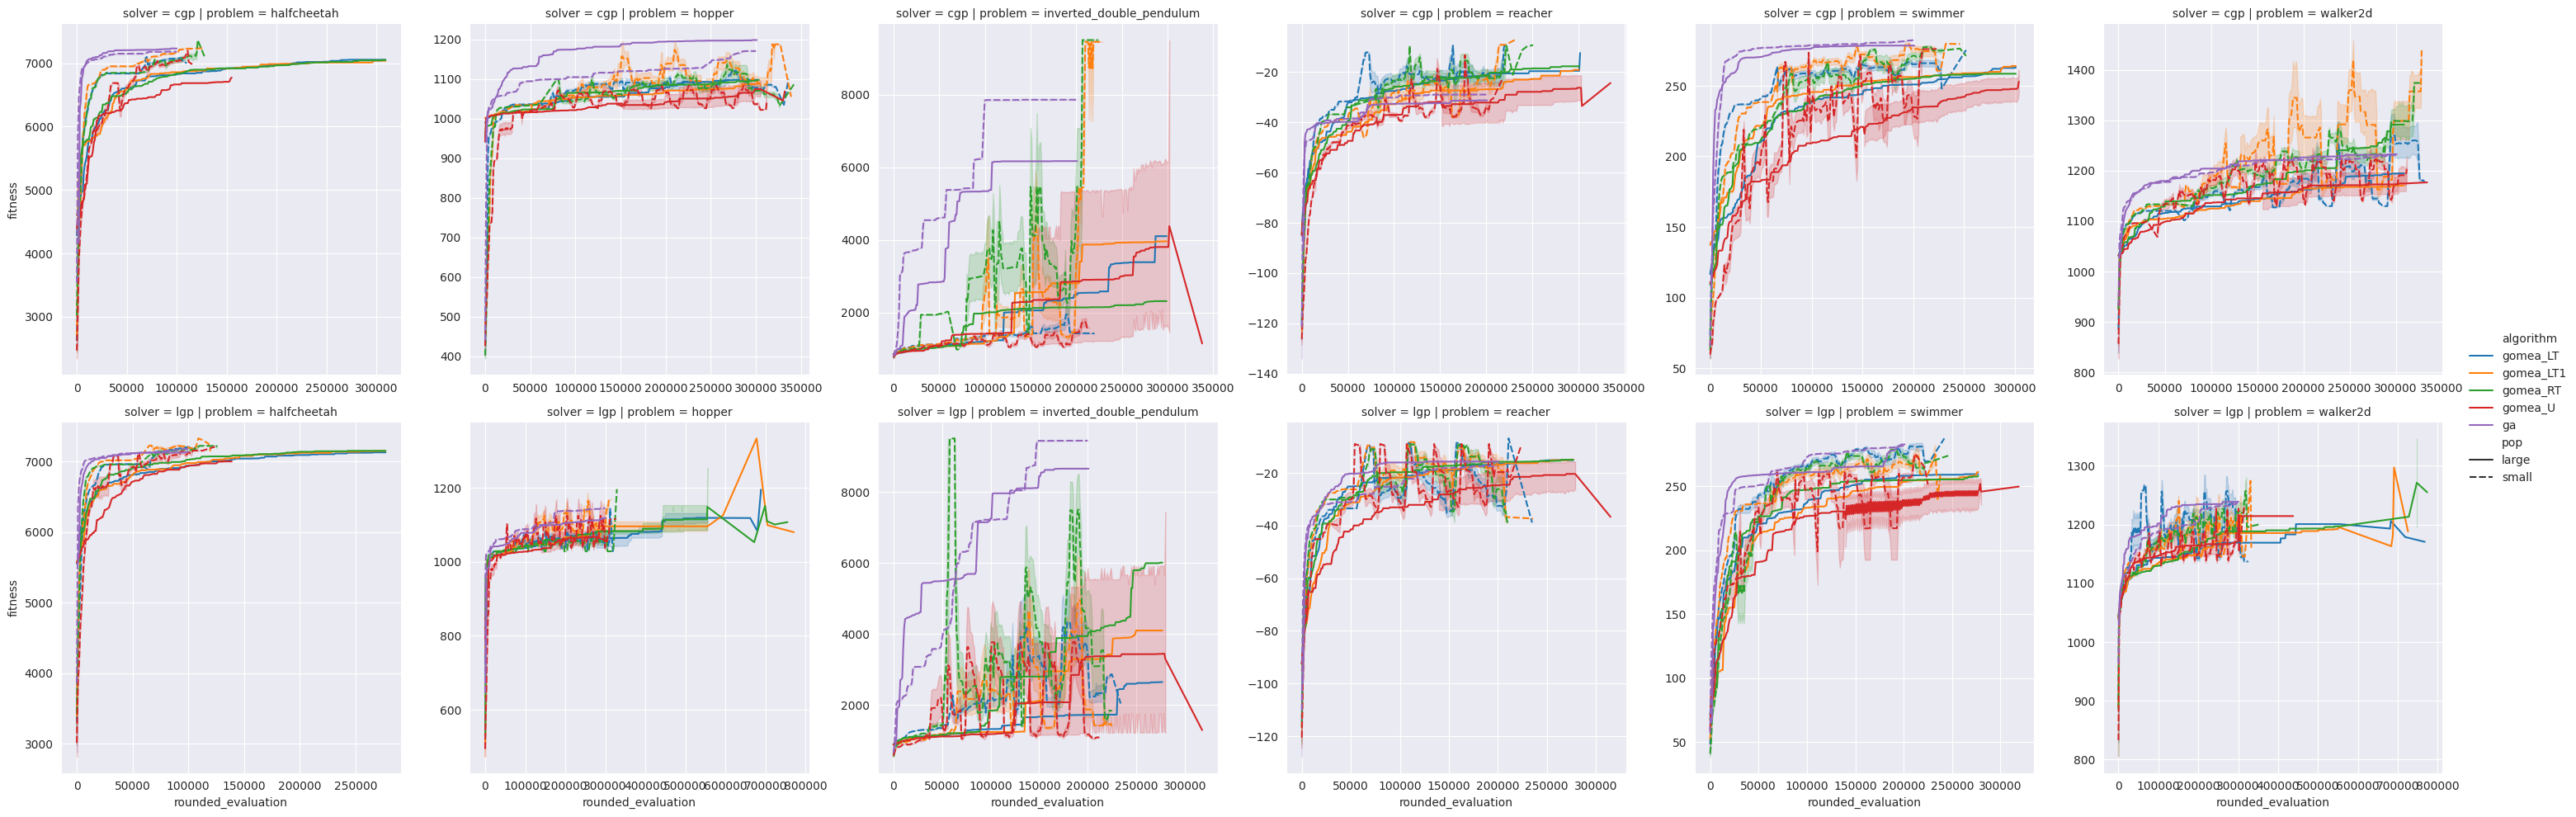

In [5]:
agg_df = (
    control_df
    .groupby(["rounded_evaluation", "evaluation", "problem", "algorithm", "solver", "pop"])
    .mean()
    .reset_index()
)
sns.relplot(
    data=agg_df,
    x="rounded_evaluation",
    y="fitness",
    style="pop",
    row="solver",
    col="problem",
    hue="algorithm",
    kind="line",
    facet_kws={'sharey': False, 'sharex': False}
)
plt.show()

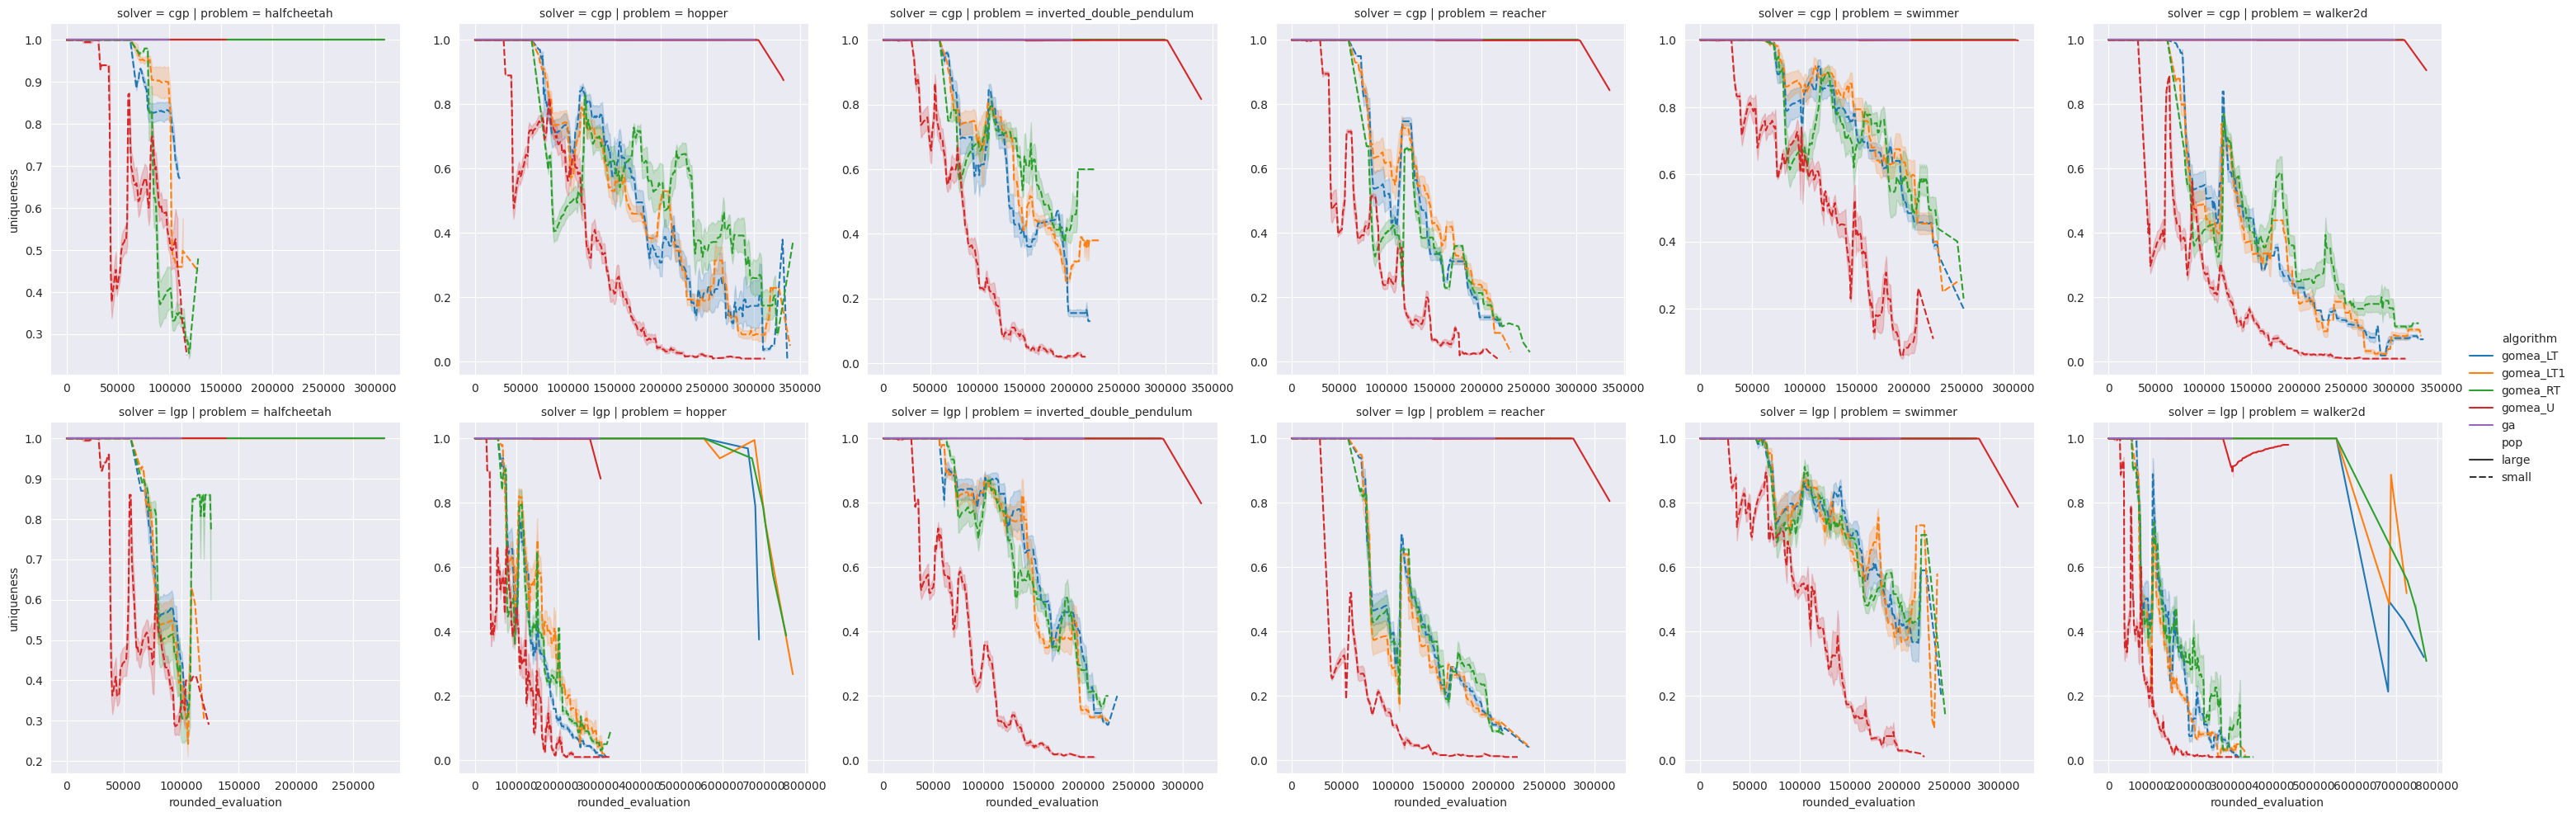

In [6]:
sns.relplot(
    agg_df,
    x="rounded_evaluation",
    y="uniqueness",
    style="pop",
    col="problem",
    row="solver",
    hue="algorithm",
    kind="line",
    facet_kws={'sharey': False, 'sharex': False}
)
plt.show()

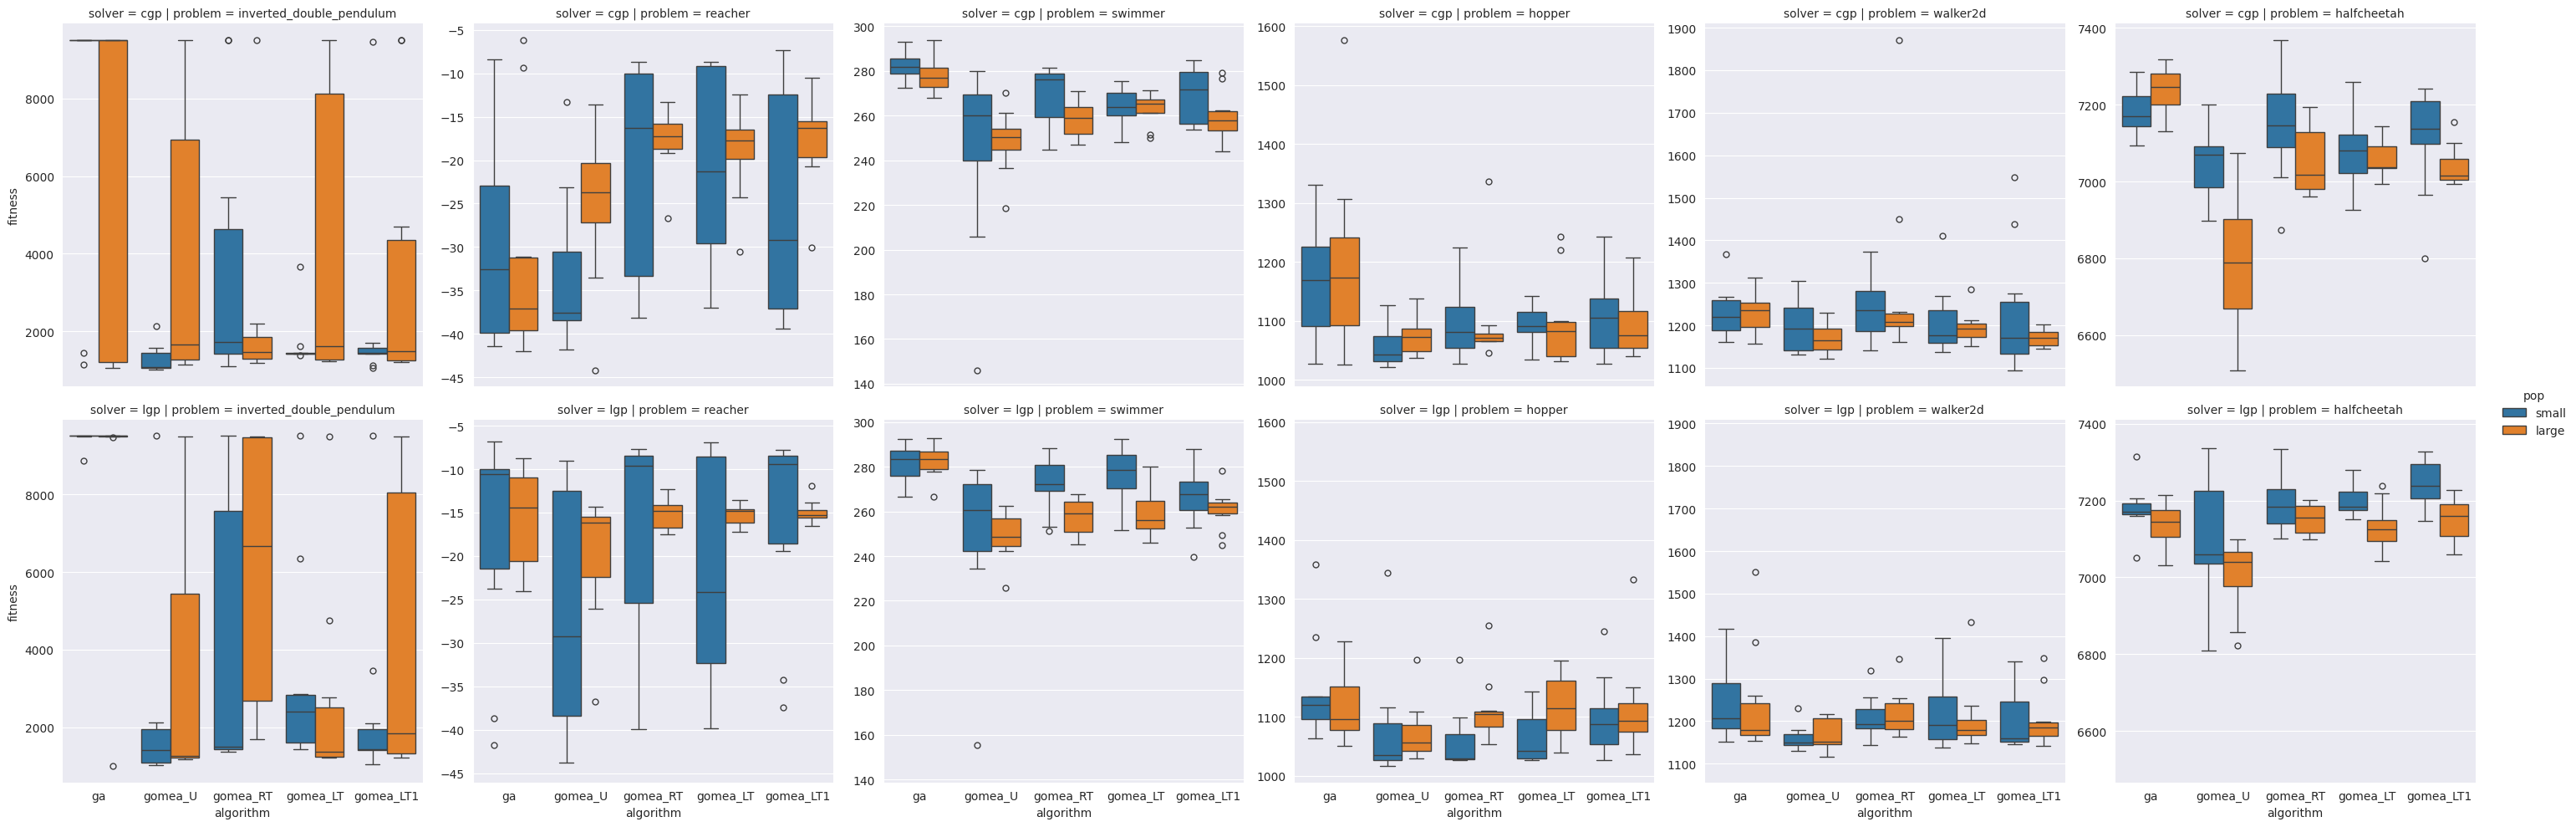

In [20]:
control_df["max_eval"] = control_df.groupby(["algorithm", "problem", "seed", "pop", "solver"])["evaluation"].transform(
    "max")
final_control_df = control_df[control_df["evaluation"] == control_df["max_eval"]].drop(columns="max_eval")
sns.catplot(
    data=final_control_df, x='algorithm', y='fitness', hue="pop", row="solver",
    col='problem', kind='box', sharey="col"
)
plt.show()

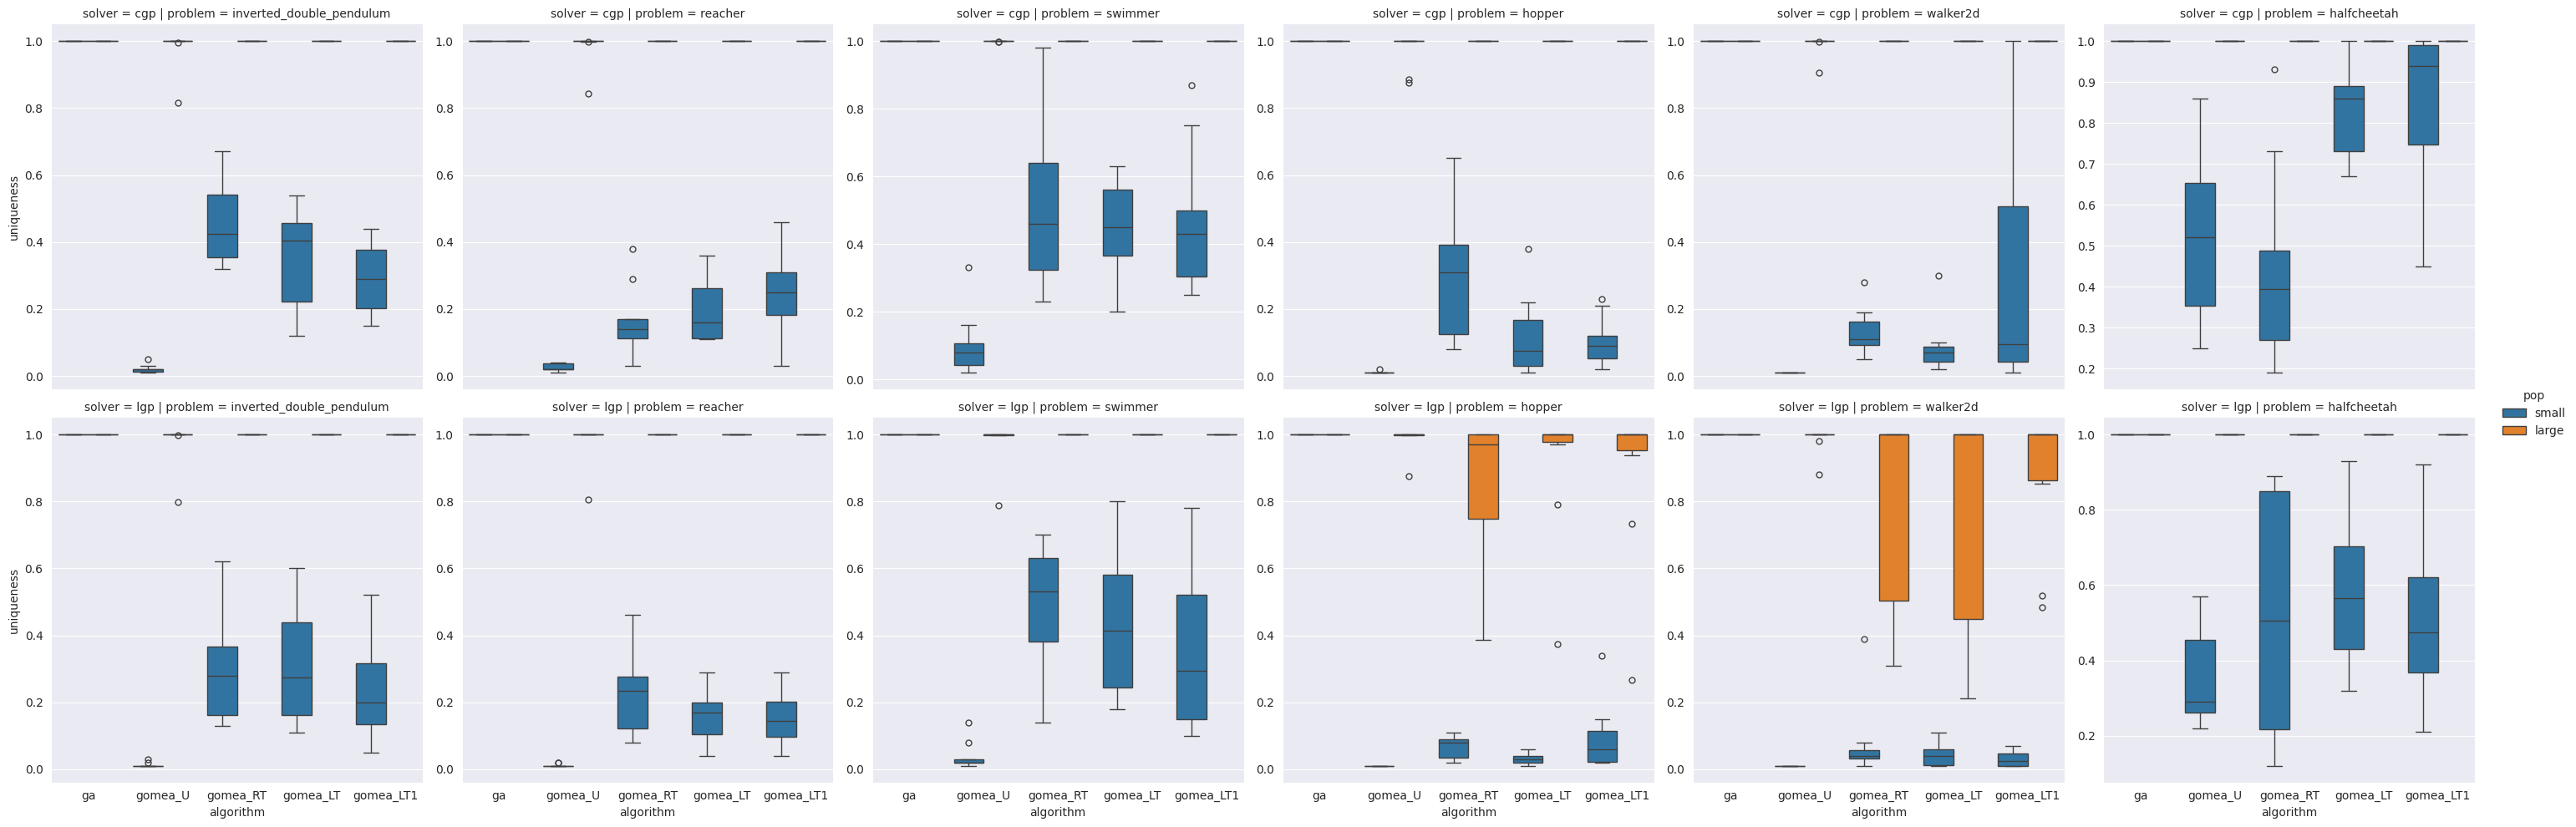

In [5]:
sns.catplot(
    data=final_control_df, x='algorithm', y='uniqueness', hue="pop",
    col='problem', kind='box', row="solver",
    sharey=False
)
plt.show()

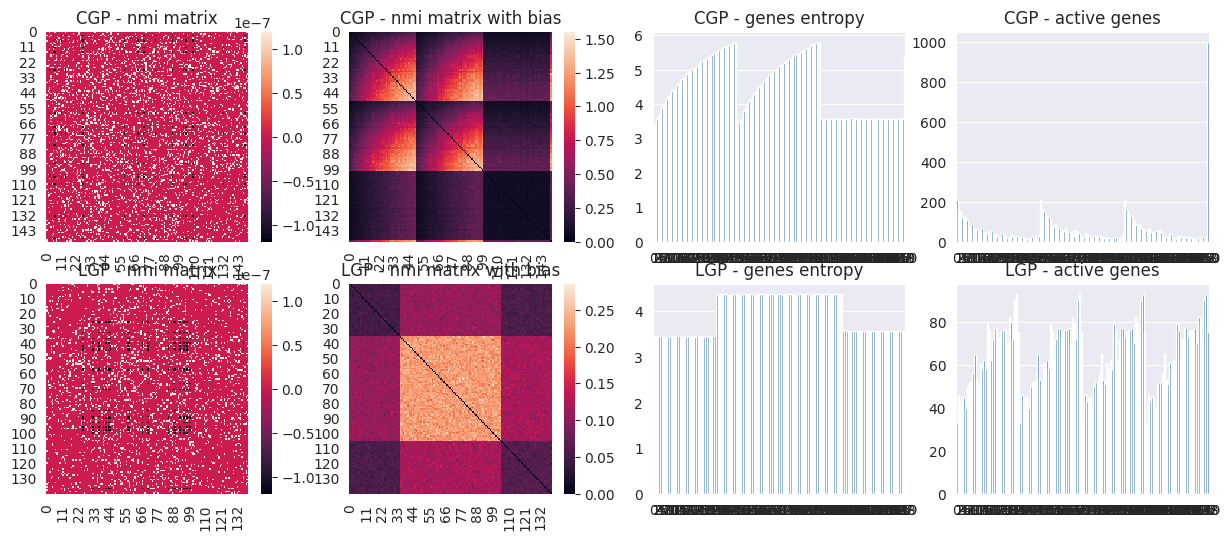

In [10]:
import jax.numpy as jnp

seed = 5
environment = "inverted_double_pendulum"
pop_type = "_large_pop"
solvers = ["cgp", "lgp"]
zero_diagonal = True

fig, axs = plt.subplots(2, 4)
fig.set_figwidth(15)
fig.set_figheight(6)

for solver_idx, solver in enumerate(solvers):
    base_path = f"../results/control/gomea_{solver}_{environment}_LT_{seed}_fi{pop_type}"
    nmi_matrix = jnp.load(f"{base_path}/nmi_matrix.npy")
    nmi_matrix_biased = jnp.load(f"{base_path}/nmi_matrix_biased.npy")
    if zero_diagonal:
        for i in range(len(nmi_matrix)):
            nmi_matrix = nmi_matrix.at[i, i].set(0.)
            nmi_matrix_biased = nmi_matrix_biased.at[i, i].set(0.)
    unique_genes = jnp.load(f"{base_path}/unique_genes.npy")
    activity_count = jnp.load(f"{base_path}/activity_count.npy")
    sns.heatmap(nmi_matrix, ax=axs[solver_idx, 0])
    axs[solver_idx, 0].set_title(f'{solver.upper()} - nmi matrix')
    sns.heatmap(nmi_matrix_biased, ax=axs[solver_idx, 1])
    axs[solver_idx, 1].set_title(f'{solver.upper()} - nmi matrix with bias')
    sns.barplot(unique_genes, ax=axs[solver_idx, 2])
    axs[solver_idx, 2].set_title(f'{solver.upper()} - genes entropy')
    sns.barplot(activity_count, ax=axs[solver_idx, 3])
    axs[solver_idx, 3].set_title(f'{solver.upper()} - active genes')
plt.show()

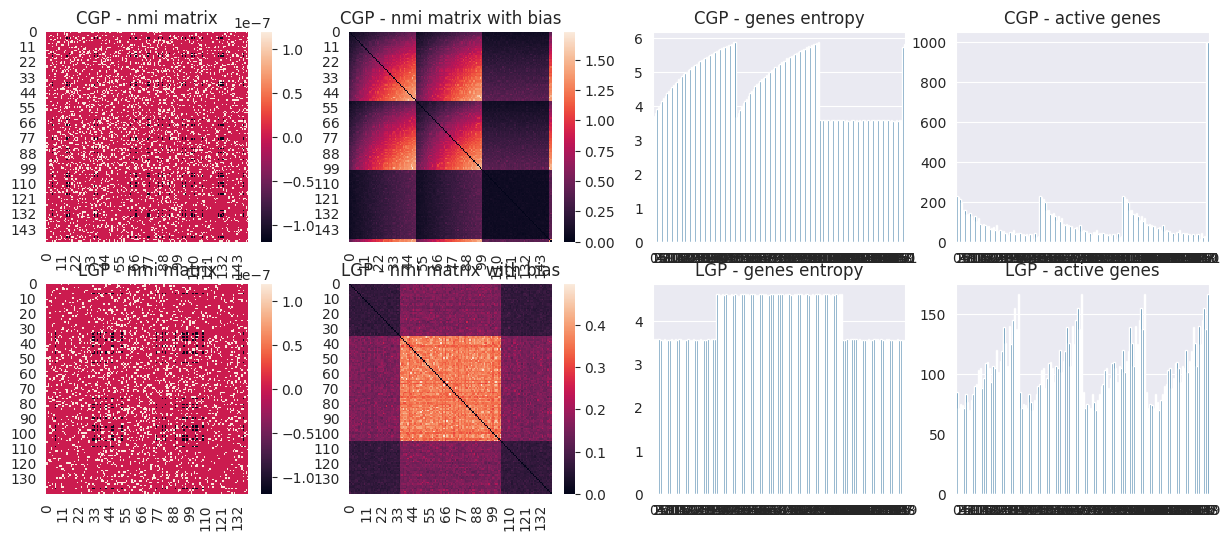

In [11]:
seed = 5
environment = "reacher"
pop_type = "_large_pop"
solvers = ["cgp", "lgp"]
zero_diagonal = True

fig, axs = plt.subplots(2, 4)
fig.set_figwidth(15)
fig.set_figheight(6)

for solver_idx, solver in enumerate(solvers):
    base_path = f"../results/control/gomea_{solver}_{environment}_LT_{seed}_fi{pop_type}"
    nmi_matrix = jnp.load(f"{base_path}/nmi_matrix.npy")
    nmi_matrix_biased = jnp.load(f"{base_path}/nmi_matrix_biased.npy")
    if zero_diagonal:
        for i in range(len(nmi_matrix)):
            nmi_matrix = nmi_matrix.at[i, i].set(0.)
            nmi_matrix_biased = nmi_matrix_biased.at[i, i].set(0.)
    unique_genes = jnp.load(f"{base_path}/unique_genes.npy")
    activity_count = jnp.load(f"{base_path}/activity_count.npy")
    sns.heatmap(nmi_matrix, ax=axs[solver_idx, 0])
    axs[solver_idx, 0].set_title(f'{solver.upper()} - nmi matrix')
    sns.heatmap(nmi_matrix_biased, ax=axs[solver_idx, 1])
    axs[solver_idx, 1].set_title(f'{solver.upper()} - nmi matrix with bias')
    sns.barplot(unique_genes, ax=axs[solver_idx, 2])
    axs[solver_idx, 2].set_title(f'{solver.upper()} - genes entropy')
    sns.barplot(activity_count, ax=axs[solver_idx, 3])
    axs[solver_idx, 3].set_title(f'{solver.upper()} - active genes')
plt.show()

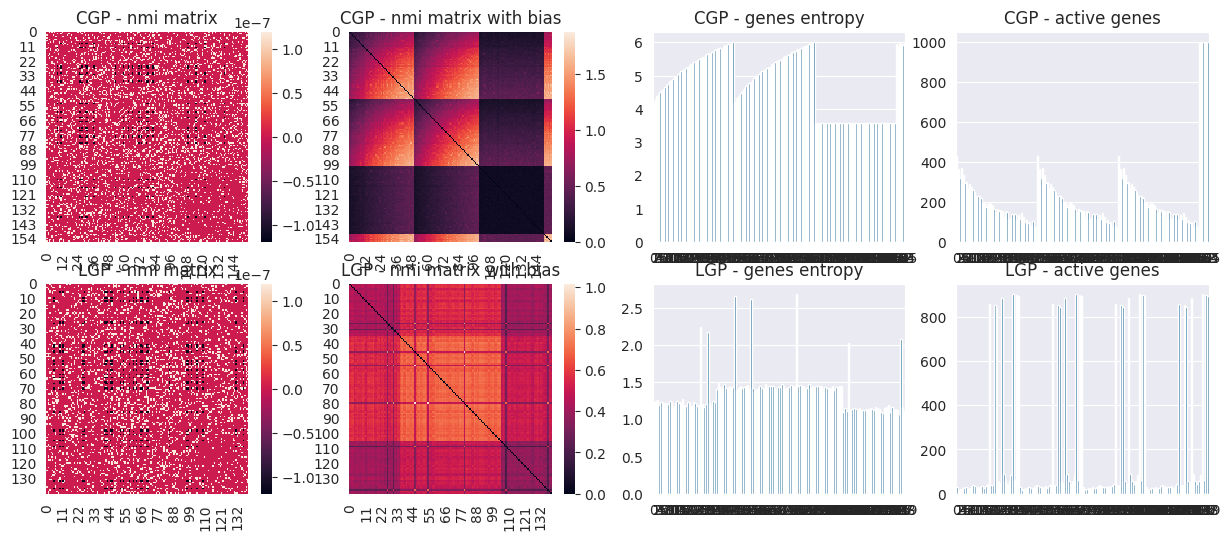

In [12]:
seed = 5
environment = "walker2d"
pop_type = "_large_pop"
solvers = ["cgp", "lgp"]
zero_diagonal = True

fig, axs = plt.subplots(2, 4)
fig.set_figwidth(15)
fig.set_figheight(6)

for solver_idx, solver in enumerate(solvers):
    base_path = f"../results/control/gomea_{solver}_{environment}_LT_{seed}_fi{pop_type}"
    nmi_matrix = jnp.load(f"{base_path}/nmi_matrix.npy")
    nmi_matrix_biased = jnp.load(f"{base_path}/nmi_matrix_biased.npy")
    if zero_diagonal:
        for i in range(len(nmi_matrix)):
            nmi_matrix = nmi_matrix.at[i, i].set(0.)
            nmi_matrix_biased = nmi_matrix_biased.at[i, i].set(0.)
    unique_genes = jnp.load(f"{base_path}/unique_genes.npy")
    activity_count = jnp.load(f"{base_path}/activity_count.npy")
    sns.heatmap(nmi_matrix, ax=axs[solver_idx, 0])
    axs[solver_idx, 0].set_title(f'{solver.upper()} - nmi matrix')
    sns.heatmap(nmi_matrix_biased, ax=axs[solver_idx, 1])
    axs[solver_idx, 1].set_title(f'{solver.upper()} - nmi matrix with bias')
    sns.barplot(unique_genes, ax=axs[solver_idx, 2])
    axs[solver_idx, 2].set_title(f'{solver.upper()} - genes entropy')
    sns.barplot(activity_count, ax=axs[solver_idx, 3])
    axs[solver_idx, 3].set_title(f'{solver.upper()} - active genes')
plt.show()

In [21]:
final_control_df["mean_fitness"] = final_control_df.groupby(["algorithm", "solver", "problem", "pop"])[
    "fitness"].transform("mean")

In [22]:
from scipy.stats import mannwhitneyu

p_val_threshold = 0.05
differences_dicts = []
for problem in final_control_df.problem.unique():
    for solver in final_control_df.solver.unique():
        for population in final_control_df["pop"].unique():
            for algorithm in final_control_df.algorithm.unique():
                if algorithm == "ga":
                    continue
                ga_df = final_control_df[
                    (final_control_df["problem"] == problem) & (final_control_df["solver"] == solver) & (
                            final_control_df["pop"] == population) & (final_control_df["algorithm"] == "ga")]
                alg_df = final_control_df[
                    (final_control_df["problem"] == problem) & (final_control_df["solver"] == solver) & (
                            final_control_df["pop"] == population) & (
                            final_control_df["algorithm"] == algorithm)]
                mean_ga = ga_df["mean_fitness"].to_list()[0]
                assert len(set(ga_df["mean_fitness"].to_list())) == 1
                mean_alg = alg_df["mean_fitness"].to_list()[0]
                assert len(set(alg_df["mean_fitness"].to_list())) == 1
                p_val = res = mannwhitneyu(ga_df["fitness"].tolist(), alg_df["fitness"].tolist()).pvalue
                result = "=" if p_val >= p_val_threshold else ("ga>gomea" if mean_ga > mean_alg else "gomea>ga")
                differences_dicts.append({
                    "problem": problem,
                    "solver": solver,
                    "population": population,
                    "algorithm": algorithm,
                    "result": result,
                    "p_value": p_val,
                })
p_values_df = pd.DataFrame(differences_dicts)
p_values_df #.head()

,problem,solver,population,algorithm,result,p_value
0,inverted_double_pendulum,cgp,small,gomea_U,ga>gomea,0.001315
1,inverted_double_pendulum,cgp,small,gomea_RT,=,0.064022
2,inverted_double_pendulum,cgp,small,gomea_LT,ga>gomea,0.005795
3,inverted_double_pendulum,cgp,small,gomea_LT1,ga>gomea,0.005795
4,inverted_double_pendulum,cgp,large,gomea_U,=,0.384673
...,...,...,...,...,...,...
91,halfcheetah,lgp,small,gomea_LT1,=,0.053903
92,halfcheetah,lgp,large,gomea_U,ga>gomea,0.002202
93,halfcheetah,lgp,large,gomea_RT,=,0.791337
94,halfcheetah,lgp,large,gomea_LT,=,0.791337
